In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# Carregando todas as bases
df_hoteis = pd.read_csv('hoteis.csv')
df_quartos = pd.read_csv('quartos.csv')
df_hospedes = pd.read_csv('hospedes.csv')
df_reservas = pd.read_csv('reservas.csv')
df_avaliacoes = pd.read_csv('avaliacoes.csv')

# tenta concatenar os dados de 2025, caso os arquivos estejam presentes na pasta. Se não estiverem, o código segue normalmente sem eles
try:
    df_res_2025 = pd.read_csv('reservas_2025.csv')
    df_aval_2025 = pd.read_csv('avaliacoes_2025.csv')
    df_reservas = pd.concat([df_reservas, df_res_2025], ignore_index=True)
    df_avaliacoes = pd.concat([df_avaliacoes, df_aval_2025], ignore_index=True)
except FileNotFoundError:
    pass # Se os arquivos de 2025 não existirem, o código continua normalmente sem eles.

In [3]:
#LIMPEZA DE DADOS DA BASE DE 'hoteis.csv'

# Categoria fora do domínio (assumindo correção para 5 estrelas o que for '6 estrelas')
df_hoteis['categoria'] = df_hoteis['categoria'].replace('6 estrelas', '5 estrelas')

# Padronização de Cidades e Estados
df_hoteis['cidade'] = df_hoteis['cidade'].str.title().replace({'Rio De Janeiro': 'Rio de Janeiro', 'Sao Paulo': 'São Paulo'})

#LIMPEZA DE DADOS DA BASE DE 'quartos.csv'

# Troca o nome do tipo de quarto que estava errado para o correto.
df_quartos['tipo_quarto'] = df_quartos['tipo_quarto'].str.capitalize().replace({'Standart': 'Standard'})

# Remove zeros ou  valor negativo.
df_quartos = df_quartos[df_quartos['capacidade'] > 0]

# Insere 0 valor base nulo com a mediana do mesmo tipo de quarto no mesmo hotel
df_quartos['valor_base'] = df_quartos.groupby(['id_hotel', 'tipo_quarto'])['valor_base'].transform(lambda x: x.fillna(x.median()))

# Remove registro do nono hotel,pois ele não existe na base de hotéis e não tem como relacionar os dados.
df_quartos = df_quartos[df_quartos['id_hotel'] != 9]


##LIMPEZA DE DADOS DA BASE DE 'hospedes.csv'

# Nomes: remove espaços e padroniza começando com letras maiúsculas
df_hospedes['nome'] = df_hospedes['nome'].str.strip().str.title()

# Gênero: padroniza para M e F
df_hospedes['genero'] = df_hospedes['genero'].str.upper().str[0] # Pega a primeira letra (M ou F)

# Remover IDs duplicados mantendo o primeiro
df_hospedes = df_hospedes.drop_duplicates(subset=['id_hospede'], keep='first')

# Padronizar estado (Ex: 'rio de janeiro' -> 'RJ', 'Sp' -> 'SP')
dict_estados = {'rio de janeiro': 'RJ', 'Sp': 'SP', 'RRJ': 'RJ'} 

df_hospedes['estado'] = df_hospedes['estado'].replace(dict_estados).str.upper()

#exporta para csv

df_hoteis.to_csv('hoteis_tratados.csv',index = False,encoding ='utf-8-sig')
df_quartos.to_csv('quartos_tratados.csv',index = False,encoding='utf-8-sig')
df_hospedes.to_csv('hospedes_tratados.csv',index = False,encoding= 'utf-8-sig')

In [4]:
#LIMPEZA DE DADOS DA BASE DE 'reservas.csv'

# Converte datas
cols_data = ['data_checkin', 'data_checkout', 'data_reserva']
for col in cols_data:
    df_reservas[col] = pd.to_datetime(df_reservas[col], errors='coerce')

# Corrige a cronologia das datas (Check-out deve ser após check-in, e data da reserva deve ser antes do check-in)
filtro_datas = (df_reservas['data_checkout'] > df_reservas['data_checkin']) & \
               (df_reservas['data_reserva'] <= df_reservas['data_checkin'])
df_reservas = df_reservas[filtro_datas]

# Remove valores nulos ou negativos de 'valor_diaria'.
df_reservas = df_reservas.dropna(subset=['valor_diaria'])
df_reservas = df_reservas[df_reservas['valor_diaria'] > 0]

# Padronizar status da reserva.
df_reservas['status_reserva'] = df_reservas['status_reserva'].str.capitalize().replace({'Cancelado': 'Cancelada'})

# Padroniza os canais de reserva (ex: 'Booking.Com' -> 'Booking.com', 'Agencia De Viagem' -> 'Agência de Viagem')
df_reservas['canal_reserva'] = df_reservas['canal_reserva'].str.title().replace({
    'Booking.Com': 'Booking.com', 'Agencia De Viagem': 'Agência de Viagem', 
    'Agência De Viagem': 'Agência de Viagem', 'Site Proprio': 'Site Próprio'
})
# Preenche canais de reserva nulos com 'Não informado'
df_reservas['canal_reserva'] = df_reservas['canal_reserva'].fillna('Não informado')

# Remover reservas órfãs (Hóspede não existe)
df_reservas = df_reservas[df_reservas['id_hospede'].isin(df_hospedes['id_hospede'])]

#LIMPEZA DE DADOS DA BASE DE 'avaliacoes.csv'
df_avaliacoes['data_avaliacao'] = pd.to_datetime(df_avaliacoes['data_avaliacao'], errors='coerce')

# Converte notas que vieram como texto (ex: '8.5', 'bom') para numérico; textos viram nulo
for col in ['nota_geral', 'nota_limpeza', 'nota_atendimento', 'nota_custo_beneficio']:
    if col in df_avaliacoes.columns:
        df_avaliacoes[col] = pd.to_numeric(df_avaliacoes[col].astype(str).str.replace(',', '.'), errors='coerce')
        # Remover notas fora do domínio 0-10
        df_avaliacoes.loc[(df_avaliacoes[col] < 0) | (df_avaliacoes[col] > 10), col] = np.nan

# Filtra avaliações apenas para reservas efetivadas (status 'Confirmada') e que tenham data de avaliação posterior ao checkout
reservas_efetivadas = df_reservas[df_reservas['status_reserva'] == 'Confirmada']['id_reserva']
df_avaliacoes = df_avaliacoes[df_avaliacoes['id_reserva'].isin(reservas_efetivadas)]

# Data da avaliação não pode ser anterior ao checkout
# (Fazemos um merge rápido só para cruzar as datas e validar)
df_valida_datas = df_avaliacoes.merge(df_reservas[['id_reserva', 'data_checkout']], on='id_reserva')
avaliacoes_validas = df_valida_datas[df_valida_datas['data_avaliacao'] >= df_valida_datas['data_checkout']]['id_reserva']
df_avaliacoes = df_avaliacoes[df_avaliacoes['id_reserva'].isin(avaliacoes_validas)]

#exporta para csv
df_reservas.to_csv('reservas_tratadas2.csv', index=False, encoding='utf-8-sig')





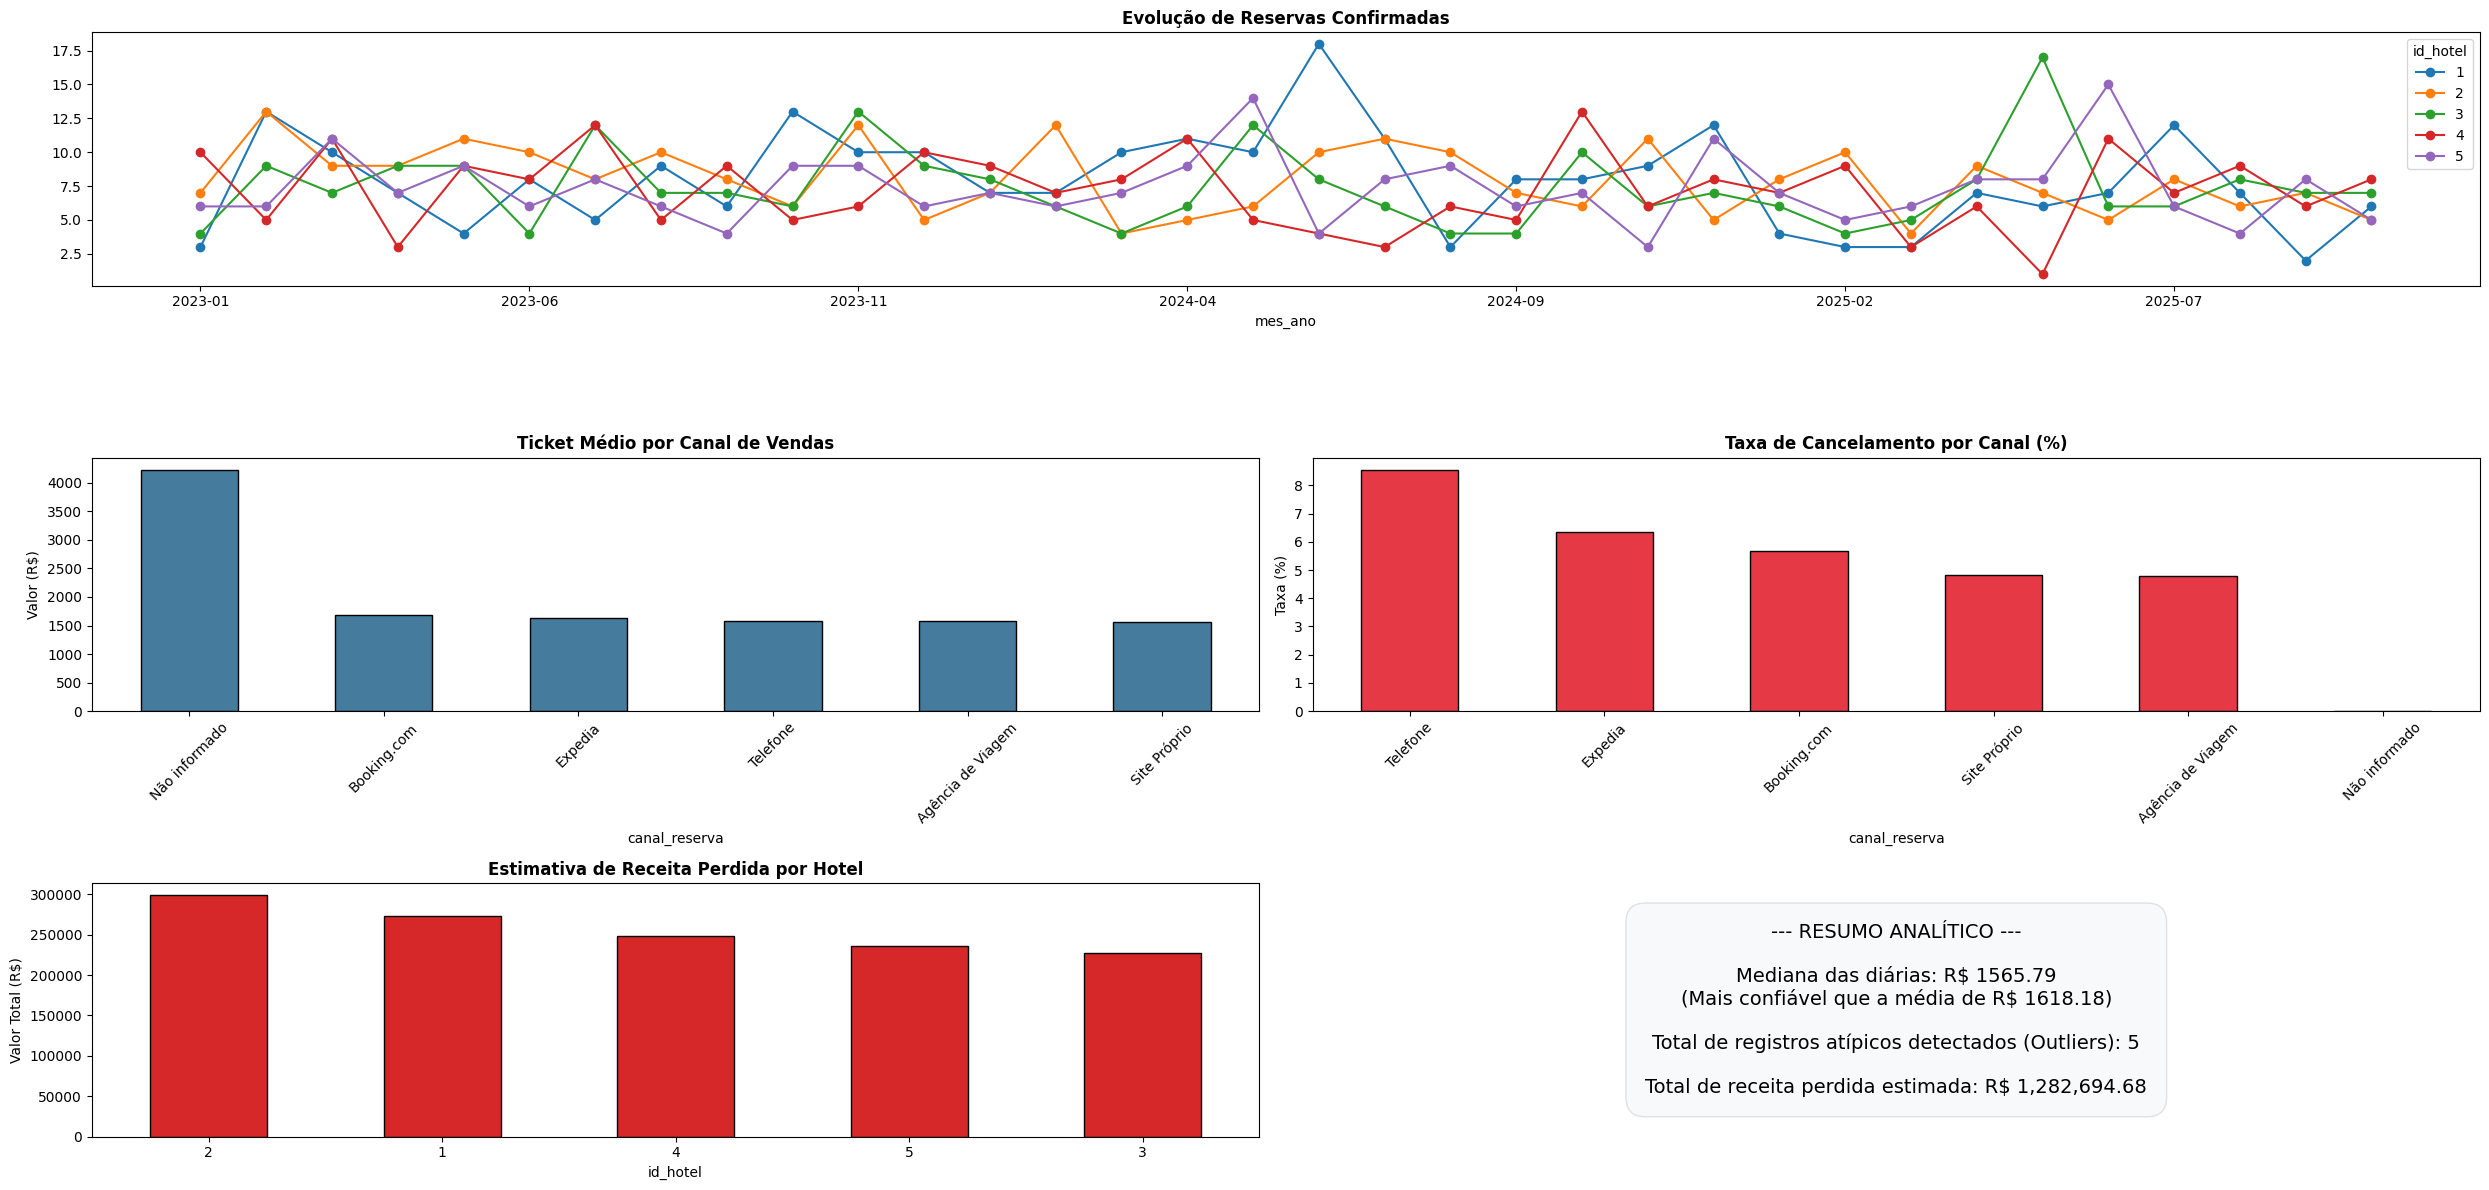

In [5]:
# 1. Medidas de Tendência e Valores Atípicos (IQR)
media_diaria = df_reservas['valor_diaria'].mean()
mediana_diaria = df_reservas['valor_diaria'].median()

Q1 = df_reservas['valor_diaria'].quantile(0.25)
Q3 = df_reservas['valor_diaria'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR
outliers_diaria = df_reservas[df_reservas['valor_diaria'] > limite_superior]

# 2. Volume Mensal de Reservas Confirmadas
df_confirmadas = df_reservas[df_reservas['status_reserva'] == 'Confirmada'].copy()
df_confirmadas['mes_ano'] = df_confirmadas['data_checkin'].dt.to_period('M').astype(str)
evolucao = df_confirmadas.groupby(['id_hotel', 'mes_ano']).size().reset_index(name='qtd')
pivot_evolucao = evolucao.pivot(index='mes_ano', columns='id_hotel', values='qtd').fillna(0)

# 3. Ticket Médio e Cancelamentos por Canal
ticket_medio = df_reservas.groupby('canal_reserva')['valor_diaria'].mean().sort_values(ascending=False)

total_canal = df_reservas.groupby('canal_reserva').size()
canceladas_canal = df_reservas[df_reservas['status_reserva'] == 'Cancelada'].groupby('canal_reserva').size()
taxa_cancelamento = (canceladas_canal / total_canal * 100).fillna(0).sort_values(ascending=False)

# 4. Impacto Financeiro (Receita Perdida por No-show/Cancelamento)
df_reservas['dias_estadia'] = (df_reservas['data_checkout'] - df_reservas['data_checkin']).dt.days
df_reservas['dias_estadia'] = df_reservas['dias_estadia'].replace(0, 1)
df_reservas['valor_total'] = df_reservas['valor_diaria'] * df_reservas['dias_estadia'].round(2)

df_perdas = df_reservas[df_reservas['status_reserva'].isin(['Cancelada', 'No-show'])]
receita_perdida = df_perdas.groupby('id_hotel')['valor_total'].sum().sort_values(ascending=False)


#(MATPLOTLIB)



fig = plt.figure(figsize=(25, 12))
gs = fig.add_gridspec(3, 2)

# Gráfico 1 ocupando a linha inteira
ax1 = fig.add_subplot(gs[0, :])
pivot_evolucao.plot(kind='line', marker='o', ax=ax1)
ax1.set_title('Evolução de Reservas Confirmadas', fontweight='bold')

# Gráfico 2
ax2 = fig.add_subplot(gs[1, 0])
ticket_medio.plot(kind='bar', color='#457b9d', edgecolor='black', ax=ax2)
ax2.set_title('Ticket Médio por Canal de Vendas', fontweight='bold')
ax2.set_ylabel('Valor (R$)')
ax2.tick_params(axis='x', rotation=45)

# Gráfico 3
ax3 = fig.add_subplot(gs[1, 1])
taxa_cancelamento.plot(kind='bar', color='#e63946', edgecolor='black', ax=ax3)
ax3.set_title('Taxa de Cancelamento por Canal (%)', fontweight='bold')
ax3.set_ylabel('Taxa (%)')
ax3.tick_params(axis='x', rotation=45)

# Gráfico 4
ax4 = fig.add_subplot(gs[2, 0])
receita_perdida.plot(kind='bar', color='#d62828', edgecolor='black', ax=ax4)
ax4.set_title('Estimativa de Receita Perdida por Hotel', fontweight='bold')
ax4.set_ylabel('Valor Total (R$)')
ax4.tick_params(axis='x', rotation=0)


# Gráfico 5 - Resumo Analítico (Texto)
ax5 = fig.add_subplot(gs[2,1])

# Remove os eixos (linhas e números) para deixar apenas o texto
ax5.axis('off') 

# Montando o texto com quebras de linha (\n)
texto_resumo = (
    "--- RESUMO ANALÍTICO ---\n\n"
    f"Mediana das diárias: R$ {mediana_diaria:.2f}\n"
    f"(Mais confiável que a média de R$ {media_diaria:.2f})\n\n"
    f"Total de registros atípicos detectados (Outliers): {len(outliers_diaria)}\n\n"
    f"Total de receita perdida estimada: R$ {receita_perdida.sum():,.2f}"
)

# Inserindo o texto no centro da área (0.5, 0.5)
ax5.text(0.5, 0.5, texto_resumo, 
         fontsize=14, 
         ha='center', # Alinhamento horizontal no centro
         va='center', # Alinhamento vertical no centro
         bbox=dict(boxstyle='round,pad=1', facecolor='#f8f9fa', edgecolor='#dee2e6')) # Cria uma "caixa" bonitinha ao redor

plt.tight_layout()
plt.show()

In [6]:
outliers_diaria.to_csv('outliers_diaria.csv', index=False, encoding='utf-8-sig')

In [7]:
# Exportando para CSV
df_reservas.to_csv('reservas_tratadas.csv', index=False, encoding='utf-8-sig')
df_avaliacoes.to_csv('avaliacoes_tratadas.csv', index=False, encoding='utf-8-sig')
df_hoteis.to_csv('hoteis_tratados.csv',index = False,encoding ='utf-8-sig')
df_quartos.to_csv('quartos_tratados.csv',index = False,encoding='utf-8-sig')
df_hospedes.to_csv('hospedes_tratados.csv',index = False,encoding= 'utf-8-sig')

print("Tabelas exportadas para CSV com sucesso!")

Tabelas exportadas para CSV com sucesso!


In [8]:
df_hospedes_tratadas = pd.read_csv('hospedes_tratados.csv')
df_hospedes_tratadas

,id_hospede,nome,email,telefone,cidade_origem,estado,data_nascimento,genero
0,1,Carlos Pereira,carlos.pereira76@outlook.com,(24) 99935-2424,Rio de Janeiro,RJ,1969-03-24,M
1,2,Diego Alves,diego.alves29@outlook.com,(36) 99928-7873,Manaus,AM,1993-01-18,M
2,3,Bruno Ribeiro,bruno.ribeiro49@gmail.com,(54) 92674-2519,Belo Horizonte,MG,1972-03-07,M
3,4,Sandra Pereira,sandra.pereira71@yahoo.com,(26) 97201-2291,Fortaleza,CE,2001-08-18,F
4,5,Cristina Ferreira,carlossilva.semdominio,(48) 92307-4814,Recife,PE,1957-11-08,F
...,...,...,...,...,...,...,...,...
395,396,Carolina Castro,carolina.castro87@hotmail.com,(19) 97269-4610,Fortaleza,CE,1985-02-09,F
396,397,Renata Moreira,renata.moreira12@outlook.com,(44) 95067-5706,Manaus,AM,1955-12-27,F
397,398,Fernanda Dias,fernanda.dias96@hotmail.com,(38) 95408-3994,Salvador,BA,1985-06-12,F
398,399,Felipe Alves,felipe.alves14@gmail.com,(42) 96833-3555,São Paulo,SP,1968-04-07,M


In [9]:
df_avaliacoes_tratadas = pd.read_csv('avaliacoes_tratadas.csv')
df_avaliacoes_tratadas

,id_avaliacao,id_reserva,nota_geral,nota_limpeza,nota_atendimento,nota_custo_beneficio,comentario,data_avaliacao
0,1,280,NaN,7.2,8.6,8.1,Staff muito atencioso.,2023-07-13
1,2,312,9.4,5.7,9.8,5.4,Custo-benefício muito bom.,2024-05-21
2,3,727,8.1,5.4,7.7,8.4,"Ótima estadia, recomendo!",2024-05-20
3,5,726,8.5,7.8,6.0,7.4,Staff muito atencioso.,2023-06-26
4,6,850,5.2,NaN,9.0,7.6,"Atendimento muito bom, quarto confortável.",2024-06-19
...,...,...,...,...,...,...,...,...
868,2218,1152,10.0,8.1,7.3,5.9,Superou as expectativas.,2025-08-28
869,2219,1060,9.5,6.4,6.4,8.3,"Atendimento excelente, quarto limpo.",2025-06-29
870,2220,1354,7.9,9.7,6.5,10.0,"Atendimento excelente, quarto limpo.",2025-05-30
871,2221,1246,6.3,8.9,9.8,7.2,Boa relação custo-benefício.,2025-06-24


In [10]:
df_reservas_tratadas = pd.read_csv('reservas_tratadas.csv')
df_reservas_tratadas

,id_reserva,id_hospede,id_quarto,id_hotel,data_checkin,data_checkout,canal_reserva,valor_diaria,status_reserva,data_reserva,dias_estadia,valor_total
0,1,203,Q026,3,2024-10-28,2024-10-29,Site Próprio,2344.25,Confirmada,2024-10-21,1,2344.25
1,2,30,Q033,3,2024-06-03,2024-06-07,Site Próprio,469.17,Confirmada,2024-05-07,4,1876.68
2,3,47,Q004,1,2024-07-18,2024-07-25,Site Próprio,2358.47,Confirmada,2024-07-10,7,16509.29
3,4,322,Q023,2,2024-08-19,2024-08-20,Telefone,1743.13,Confirmada,2024-08-15,1,1743.13
4,5,286,Q013,2,2023-05-17,2023-05-22,Agência de Viagem,617.85,Confirmada,2023-05-09,5,3089.25
...,...,...,...,...,...,...,...,...,...,...,...,...
1465,1496,115,Q001,1,2025-07-11,2025-07-16,Telefone,600.66,Confirmada,2025-07-08,5,3003.30
1466,1497,285,Q015,2,2025-07-07,2025-07-16,Agência de Viagem,835.44,No-show,2025-06-11,9,7518.96
1467,1498,291,Q046,5,2025-08-24,2025-08-26,Site Próprio,2235.72,Confirmada,2025-08-19,2,4471.44
1468,1499,51,Q048,5,2025-01-05,2025-01-08,Expedia,2495.88,Cancelada,2024-11-22,3,7487.64


In [11]:
outliers_diaria.to_csv('outliers_diaria.csv', index=False, encoding='utf-8-sig')